In [0]:
# =========================================================
# Análise: Arenas com mais partidas e desempenho dos clubes
# Pergunta: Quais arenas receberam mais partidas e como os clubes performam nelas?
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Consulta SQL
# ---------------------------------------------------------
query = """
WITH partidas_por_arena AS (
    SELECT
        arena,
        COUNT(*) AS total_partidas
    FROM fato_partida
    GROUP BY arena
),

desempenho_mandante AS (
    SELECT
        arena,
        COUNT(*) AS jogos,
        SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS vitorias_mandante,
        ROUND(
            CAST(SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS DOUBLE)
            / CAST(COUNT(*) AS DOUBLE) * 100,
            2
        ) AS taxa_vitoria_mandante_pct
    FROM fato_partida
    GROUP BY arena
)

SELECT
    p.arena,
    p.total_partidas,
    d.jogos,
    d.vitorias_mandante,
    d.taxa_vitoria_mandante_pct
FROM partidas_por_arena p
JOIN desempenho_mandante d
    ON p.arena = d.arena
ORDER BY p.total_partidas DESC
"""

# Executa a consulta
df_resultado = spark.sql(query)

# Exibe o resultado tabular (fica salvo no .ipynb)
display(df_resultado)

arena,total_partidas,jogos,vitorias_mandante,taxa_vitoria_mandante_pct
Maracanã,631,631,324,51.35
Mineirão,459,459,246,53.59
Morumbi,413,413,229,55.45
Couto Pereira,295,295,140,47.46
Serra Dourada,235,235,115,48.94
Orlando Scarpelli,219,219,95,43.38
Pacaembu,213,213,116,54.46
Estádio Raimundo Sampaio,201,201,101,50.25
Beira Rio,200,200,117,58.5
Vila Belmiro,192,192,105,54.69


**Gráfico de apoio**

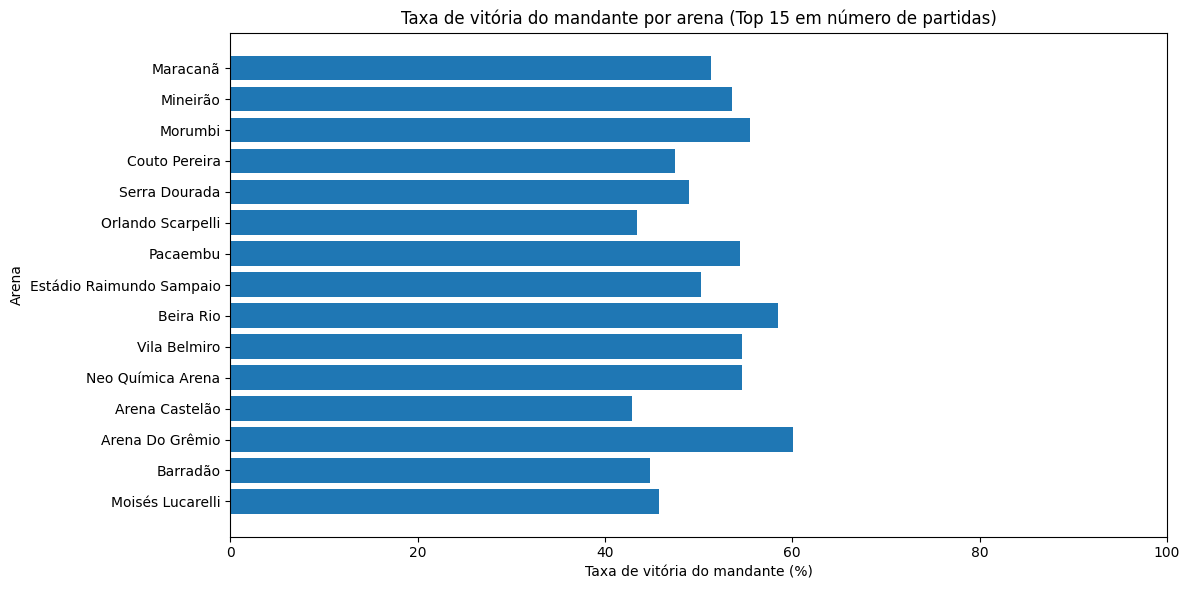

In [0]:
# ---------------------------------------------------------
# Taxa de vitória do mandante (%) por arena
# Considerando as arenas com maior número de partidas
# ---------------------------------------------------------

# Converte para Pandas (limitando às 15 arenas mais recorrentes)
pdf = df_resultado.limit(15).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(
    pdf["arena"],
    pdf["taxa_vitoria_mandante_pct"]
)
plt.xlabel("Taxa de vitória do mandante (%)")
plt.ylabel("Arena")
plt.title("Taxa de vitória do mandante por arena (Top 15 em número de partidas)")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
